### Phân tích dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [2]:
df = pd.read_csv('Data/LienHuong.csv')  
# bỏ khoảng trắng ở đầu và cuối tên cột
df.columns = df.columns.str.strip()
df.head()

,Date,Precipitation,Temperature,Relative Humidity,Wind Speed
0,1/1/1985,0.0,24.12,66.46,26.87
1,1/2/1985,0.0,24.27,66.08,26.60
2,1/3/1985,0.1,25.02,61.42,22.44
3,1/4/1985,0.2,25.26,60.54,22.89
4,1/5/1985,0.0,25.05,59.92,24.88


### 1.Thông tin dữ liệu

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12209 entries, 0 to 12208
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               12207 non-null  object 
 1   Precipitation      12202 non-null  float64
 2   Temperature        12205 non-null  float64
 3   Relative Humidity  12206 non-null  float64
 4   Wind Speed         12206 non-null  float64
dtypes: float64(4), object(1)
memory usage: 477.0+ KB


In [4]:
df.columns

Index(['Date', 'Precipitation', 'Temperature', 'Relative Humidity',
       'Wind Speed'],
      dtype='object')

### 2.Thống kê dữ liệu

In [5]:
# Kiểm tra cấu trúc dữ liệu
df.info()
# Kích thước dữ liệu
print("Kích thước dữ liệu:",df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12209 entries, 0 to 12208
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               12207 non-null  object 
 1   Precipitation      12202 non-null  float64
 2   Temperature        12205 non-null  float64
 3   Relative Humidity  12206 non-null  float64
 4   Wind Speed         12206 non-null  float64
dtypes: float64(4), object(1)
memory usage: 477.0+ KB
Kích thước dữ liệu: (12209, 5)


In [6]:
# Thống kê mô tả tổng quát
df.describe()

,Precipitation,Temperature,Relative Humidity,Wind Speed
count,12202.000000,12205.000000,12206.000000,12206.000000
mean,1.606745,26.361401,76.356003,17.188073
std,5.243681,2.660680,70.523075,11.924787
min,0.000000,19.580000,0.780000,1.070000
25%,0.000000,25.310000,69.290000,10.310000
50%,0.000000,26.400000,74.620000,17.150000
75%,0.700000,27.560000,81.830000,23.330000
max,127.100000,254.000000,7779.000000,1001.000000


In [7]:
# Kiểm tra phân bố lệch
df.select_dtypes(include='number').skew().to_frame("skew")

,skew
Precipitation,8.237839
Temperature,51.232414
Relative Humidity,106.846988
Wind Speed,46.039840


In [8]:
data = df[["Precipitation","Temperature","Relative Humidity","Wind Speed"]]
data

,Precipitation,Temperature,Relative Humidity,Wind Speed
0,0.0,24.12,66.46,26.87
1,0.0,24.27,66.08,26.60
2,0.1,25.02,61.42,22.44
3,0.2,25.26,60.54,22.89
4,0.0,25.05,59.92,24.88
...,...,...,...,...
12204,0.0,28.81,74.21,10.25
12205,0.0,27.53,77.42,8.47
12206,0.0,28.70,73.12,13.04
12207,0.0,29.13,71.79,8.29


#### Đo lường xu hướng trung tâm

In [9]:
data.mean().to_frame("mean")

,mean
Precipitation,1.606745
Temperature,26.361401
Relative Humidity,76.356003
Wind Speed,17.188073


In [10]:
data.median().to_frame("median")

,median
Precipitation,0.00
Temperature,26.40
Relative Humidity,74.62
Wind Speed,17.15


In [11]:
data.mode().iloc[0].to_frame("Mode")

,Mode
Precipitation,0.00
Temperature,26.00
Relative Humidity,74.71
Wind Speed,17.94


#### Đo lường xu hướng phân tán

In [12]:
# Độ lệch chuẩn
data.std().to_frame("Std")

,Std
Precipitation,5.243681
Temperature,2.660680
Relative Humidity,70.523075
Wind Speed,11.924787


In [13]:
# data.var()
data.var().to_frame("Var")

,Var
Precipitation,27.496195
Temperature,7.079217
Relative Humidity,4973.504066
Wind Speed,142.200555


In [14]:
data.min().to_frame("Giá trị nhỏ nhất")

,Giá trị nhỏ nhất
Precipitation,0.00
Temperature,19.58
Relative Humidity,0.78
Wind Speed,1.07


In [15]:
data.max().to_frame("Giá trị lớn nhất")

,Giá trị lớn nhất
Precipitation,127.1
Temperature,254.0
Relative Humidity,7779.0
Wind Speed,1001.0


In [16]:
data_range = data.max()-data.min()
data_range.to_frame("Phạm vi")

,Phạm vi
Precipitation,127.10
Temperature,234.42
Relative Humidity,7778.22
Wind Speed,999.93


#### Đo lường vị trí

In [17]:
position_summary_df = pd.DataFrame({
    "Q1 (25%)": data.quantile(0.25),
    "Q2 (50% - Median)": data.quantile(0.50),
    "Q3 (75%)": data.quantile(0.75)
})
display(position_summary_df)

,Q1 (25%),Q2 (50% - Median),Q3 (75%)
Precipitation,0.00,0.00,0.70
Temperature,25.31,26.40,27.56
Relative Humidity,69.29,74.62,81.83
Wind Speed,10.31,17.15,23.33


#### Đo lường mức tương quan

In [18]:
data.corr()

,Precipitation,Temperature,Relative Humidity,Wind Speed
Precipitation,1.000000,-0.056403,0.055283,-0.130400
Temperature,-0.056403,1.000000,-0.001326,-0.193146
Relative Humidity,0.055283,-0.001326,1.000000,-0.030407
Wind Speed,-0.130400,-0.193146,-0.030407,1.000000


### 3. Xử lý dữ 

In [19]:
# Chuẩn hóa dữ liệu
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [20]:
#sắp xếp dữ liệu theo thời gian
df.sort_index()

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-01,0.0,24.12,66.46,26.87
1985-01-02,0.0,24.27,66.08,26.60
1985-01-03,0.1,25.02,61.42,22.44
1985-01-04,0.2,25.26,60.54,22.89
1985-01-05,0.0,25.05,59.92,24.88
...,...,...,...,...
2018-05-30,0.0,28.70,73.12,13.04
2018-05-31,0.0,29.13,71.79,8.29
2018-06-01,1.7,28.73,75.83,4.87


#### Xử lý giá trị thiếu

In [21]:
# Kiểm tra 
df.isnull().sum()

Precipitation        7
Temperature          4
Relative Humidity    3
Wind Speed           3
dtype: int64

In [22]:
df[df.isnull().any(axis=1)]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-25,NaN,24.84,67.58,25.38
1985-01-29,NaN,24.64,68.54,29.71
1985-03-30,NaN,26.06,62.50,15.74
1987-05-28,NaN,29.19,67.00,10.36
1990-04-24,NaN,28.79,71.83,12.27
1991-01-03,0.0,NaN,72.46,24.61
NaT,NaN,NaN,NaN,NaN
NaT,NaN,NaN,NaN,NaN
1994-11-05,0.0,24.50,75.58,NaN


In [23]:
# Xóa dòng trắng
df = df[~df.index.isna()]

In [24]:
df.index.isna().sum()

np.int64(0)

In [25]:
df[df.isnull().any(axis=1)]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-25,NaN,24.84,67.58,25.38
1985-01-29,NaN,24.64,68.54,29.71
1985-03-30,NaN,26.06,62.50,15.74
1987-05-28,NaN,29.19,67.00,10.36
1990-04-24,NaN,28.79,71.83,12.27
1991-01-03,0.0,NaN,72.46,24.61
1994-11-05,0.0,24.50,75.58,NaN
1995-04-18,0.0,27.68,NaN,8.65
1995-05-27,2.6,NaN,76.33,13.91


In [26]:
# Kiểm tra dữ liệu thiếu Precipitation
df[df['Precipitation'].isnull()]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-25,NaN,24.84,67.58,25.38
1985-01-29,NaN,24.64,68.54,29.71
1985-03-30,NaN,26.06,62.50,15.74
1987-05-28,NaN,29.19,67.00,10.36
1990-04-24,NaN,28.79,71.83,12.27


In [27]:
mode_value = df['Precipitation'].mode()[0]
mode_value

np.float64(0.0)

In [28]:
df['Precipitation'] = df['Precipitation'].fillna(mode_value)

In [29]:
df['Precipitation'].isnull().sum()

np.int64(0)

In [30]:
# Kiểm tra dữ liệu thiếu Temperature
df[df['Temperature'].isnull()]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1991-01-03,0.0,NaN,72.46,24.61
1995-05-27,2.6,NaN,76.33,13.91


In [31]:
# Tính trung bình trượt 5 ngày
rolling_mean_5 = df['Temperature'].rolling(window=5, min_periods=1).mean()
# Thay thế giá trị thiếu
df['Temperature'] = df['Temperature'].fillna(rolling_mean_5)

In [32]:
df['Temperature'].isnull().sum()

np.int64(0)

In [33]:
# Kiểm tra dữ liệu thiếu Wind Speed
df[df['Wind Speed'].isnull()]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1994-11-05,0.0,24.5,75.58,NaN


In [34]:
# Xử lý Wind Speed bằng trung bình
df['Wind Speed'] = df['Wind Speed'].fillna(df['Wind Speed'].mean())

In [35]:
df['Wind Speed'].isnull().sum()

np.int64(0)

In [36]:
# Kiểm tra dữ liệu thiếu Relative Humidity
df[df['Relative Humidity'].isnull()]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1995-04-18,0.0,27.68,NaN,8.65


In [37]:
# Xử lý Relative Humidity bằng trung vị
df['Relative Humidity'] = df['Relative Humidity'].fillna(df['Relative Humidity'].median())

In [38]:
df.isnull().sum()

Precipitation        0
Temperature          0
Relative Humidity    0
Wind Speed           0
dtype: int64

#### Xử lý dữ liệu trùng lặp

In [39]:
# Kiểm tra dữ liệu trùng lặp
df.duplicated().sum()

np.int64(2)

In [40]:
# Hiển thị tất cả các dòng trùng
df[df.duplicated(keep=False)]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1994-05-10,0.0,28.57,71.38,7.38
1994-05-10,0.0,28.57,71.38,7.38
1995-06-16,7.5,28.41,78.46,11.75
1995-06-16,7.5,28.41,78.46,11.75


In [41]:
# Xóa dữ liệu trùng lặp
df.drop_duplicates(inplace=True)

In [42]:
# Kiểm tra dữ liệu trùng lặp
df.duplicated().sum()

np.int64(0)

#### Xử lý ngoại lai

In [43]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
# Kiểm tra dữ liệu ngoại lai
outliers = ((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR)))
df[outliers.any(axis=1)]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-04-25,23.5,24.28,93.58,4.58
1985-04-27,3.8,24.58,90.29,11.54
1985-04-29,5.7,25.64,82.62,3.87
1985-04-30,25.8,26.21,85.58,5.23
1985-05-01,13.3,25.25,87.04,14.08
...,...,...,...,...
2017-12-21,1.2,21.42,82.04,28.96
2017-12-25,10.6,21.37,82.00,34.01
2018-02-05,0.0,21.91,63.92,30.59


In [44]:
# Kiểm tra mưa âm
df[df['Precipitation'] < 0]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,


In [45]:
# Kiểm tra mưa quá lớn (> 200 mm)
df[df['Precipitation'] > 200]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,


In [46]:
# Kiểm tra nhiệt độ vô lý
df[(df['Temperature'] < -20) | (df['Temperature'] > 60)]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1993-10-08,0.0,254.0,80.79,13.32


In [47]:
# xử lý dữ liệu vô lý
df.loc['1993-10-08', 'Temperature'] = 25.4
df.loc[['1993-10-08']]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1993-10-08,0.0,25.4,80.79,13.32


In [48]:
# Kiểm tra nhiệt độ vô lý
df[(df['Temperature'] < -10) | (df['Temperature'] > 60)]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,


In [49]:
# Kiểm tra độ ẩm phải nằm trong [0, 100] 
df[(df['Relative Humidity'] < 20) | 
   (df['Relative Humidity'] > 100)]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1987-06-16,0.0,27.50,7779.00,21.56
1989-06-08,3.5,27.97,0.78,9.11
1990-10-21,0.0,26.44,760.00,15.84


In [50]:
df.loc['1987-06-16', 'Relative Humidity'] = 77.79
df.loc['1990-10-21', 'Relative Humidity'] = 76.0
df.loc['1989-06-08', 'Relative Humidity'] = 78.0


In [51]:
df.loc[['1987-06-16', '1990-10-21']]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1987-06-16,0.0,27.50,77.79,21.56
1990-10-21,0.0,26.44,76.00,15.84


In [52]:
# Kiểm tra độ ẩm phải nằm trong [0, 100] 
df[(df['Relative Humidity'] <= 0) | 
   (df['Relative Humidity'] > 100)]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,


In [53]:
# Kiểm tra tốc độ gió
# Gió âm
df[df['Wind Speed'] < 0]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,


In [54]:
# Gió quá lớn
df[df['Wind Speed'] > 60]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1993-06-04,0.0,29.63,67.92,1001.0


In [55]:
df.loc['1993-06-04', 'Wind Speed'] = 10.01

In [56]:
df.loc[['1993-06-04']]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1993-06-04,0.0,29.63,67.92,10.01


In [57]:
# Gió quá lớn
df[df['Wind Speed'] > 60]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,


In [58]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
# Kiểm tra dữ liệu ngoại lai
outliers = ((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR)))
df[outliers.any(axis=1)]

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-04-25,23.5,24.28,93.58,4.58
1985-04-27,3.8,24.58,90.29,11.54
1985-04-29,5.7,25.64,82.62,3.87
1985-04-30,25.8,26.21,85.58,5.23
1985-05-01,13.3,25.25,87.04,14.08
...,...,...,...,...
2017-12-21,1.2,21.42,82.04,28.96
2017-12-25,10.6,21.37,82.00,34.01
2018-02-05,0.0,21.91,63.92,30.59


#### Kiểm tra giá trị không hợp lệ

In [59]:
# Giá trị âm (bất hợp lý) - kiểm tra nhanh
cols = ["Precipitation","Temperature","Relative Humidity","Wind Speed"]
(df[cols] < 0).sum()

Precipitation        0
Temperature          0
Relative Humidity    0
Wind Speed           0
dtype: int64

In [60]:
# Kiểm tra dữ liệu chuỗi thời gian
df.asfreq('D')

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-01,0.0,24.12,66.46,26.87
1985-01-02,0.0,24.27,66.08,26.60
1985-01-03,0.1,25.02,61.42,22.44
1985-01-04,0.2,25.26,60.54,22.89
1985-01-05,0.0,25.05,59.92,24.88
...,...,...,...,...
2018-05-28,0.0,28.81,74.21,10.25
2018-05-29,0.0,27.53,77.42,8.47
2018-05-30,0.0,28.70,73.12,13.04


### 4. Trực quan dữ liệu

#### Phân tích xu hướng theo thời gian

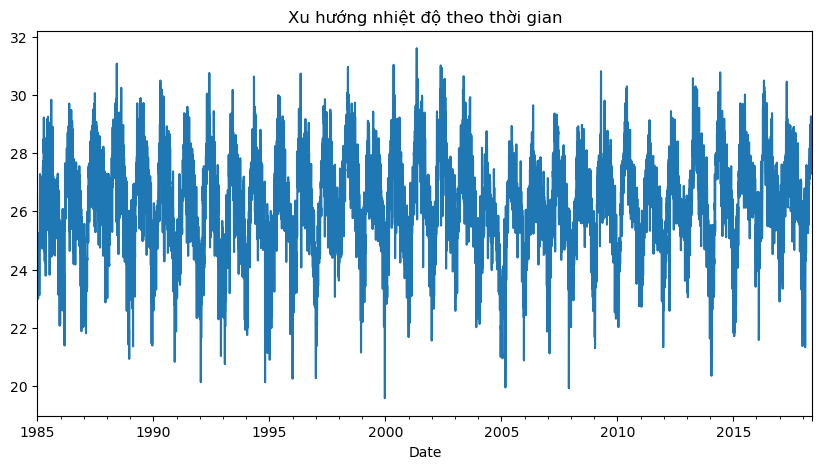

In [61]:
df['Temperature'].plot(figsize=(10,5))
plt.title("Xu hướng nhiệt độ theo thời gian")
plt.show()

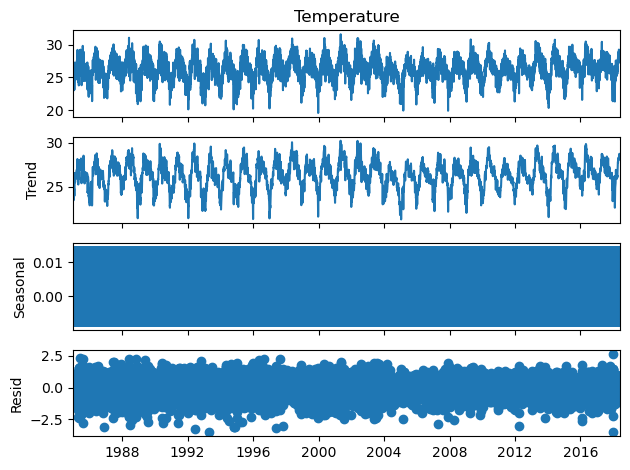

In [62]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Temperature'], model='add')
result.plot();

#### Ma trận tương quan

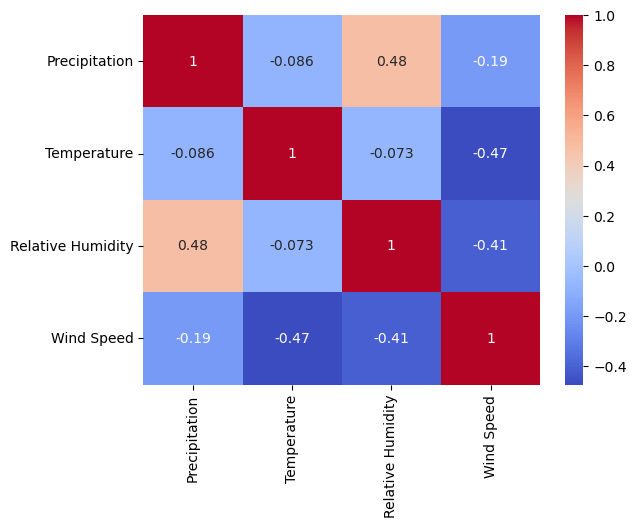

In [63]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

#### Phát hiện ngoại lai

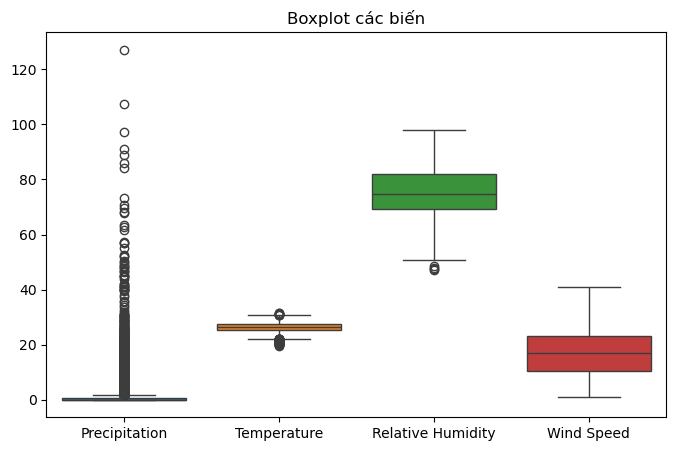

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Precipitation','Temperature',
                     'Relative Humidity','Wind Speed']])
plt.title("Boxplot các biến")
plt.show()

#### Kiểm tra phân bố lệch

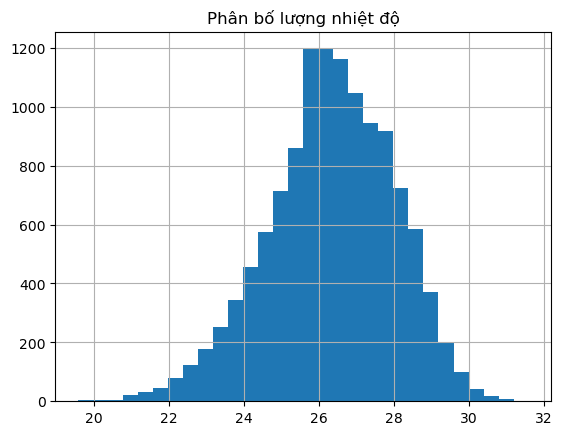

In [65]:
df['Temperature'].hist(bins=30)
plt.title("Phân bố lượng nhiệt độ")
plt.show()

In [66]:
# df.to_csv("Data/data_preprocessing.csv", index=True, encoding="utf-8")